# Question 4: The Volatility Term Premium

Characterize the volatility term premium implied by the forward vol curve and assess its reliability across tenors.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm
from scipy.optimize import brentq
from IPython.display import display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 15)

DATA_PATH = Path('Data')

# --- Setup and Data Calculation (from Q1) ---

def black_caplet_price(vol, F, K, T_expiry, discount, delta=0.25):
    if T_expiry <= 0 or vol <= 0:
        return 0
    d1 = (np.log(F / K) + 0.5 * vol**2 * T_expiry) / (vol * np.sqrt(T_expiry))
    d2 = d1 - vol * np.sqrt(T_expiry)
    return delta * discount * (F * norm.cdf(d1) - K * norm.cdf(d2))

def bootstrap_forward_vols(cap_prices, forward_rates, discount_factors, K_simple, flat_vols):
    forward_vols = {}
    sorted_maturities = sorted(cap_prices.dropna().index)
    if not sorted_maturities:
        return pd.Series(dtype=float)
        
    first_maturity = sorted_maturities[0]

    for T in np.arange(0.5, first_maturity + 0.25, 0.25):
        T = round(T, 2)
        forward_vols[T] = flat_vols.loc[first_maturity]

    for i in range(1, len(sorted_maturities)):
        T_curr = round(sorted_maturities[i], 2)
        T_prev = round(sorted_maturities[i-1], 2)

        K_new = K_simple.get(T_curr, np.nan)
        F_new = forward_rates.get((T_prev, T_curr), np.nan)
        discount_new = discount_factors.get(T_curr, np.nan)
        T_expiry_new = T_prev

        if any(np.isnan([K_new, F_new, discount_new])):
            forward_vols[T_curr] = np.nan
            continue

        inner_caplets_repriced = 0.0
        for T in np.arange(0.5, T_curr, 0.25):
            T = round(T, 2)
            T_expiry = round(T - 0.25, 2)
            if T_expiry <= 0:
                continue

            fwd_vol = forward_vols.get(T, np.nan)
            F = forward_rates.get((T_expiry, T), np.nan)
            df = discount_factors.get(T, np.nan)

            if any(np.isnan([fwd_vol, F, df])):
                continue

            inner_caplets_repriced += black_caplet_price(fwd_vol, F, K_new, T_expiry, df)

        marginal_caplet_price = cap_prices[T_curr] - inner_caplets_repriced

        if marginal_caplet_price <= 0:
            forward_vols[T_curr] = np.nan
            continue

        try:
            fwd_vol = brentq(
                lambda v: black_caplet_price(v, F_new, K_new, T_expiry_new, discount_new) - marginal_caplet_price,
                1e-6, 5.0, xtol=1e-8
            )
        except ValueError:
            forward_vols[T_curr] = np.nan
            continue

        forward_vols[T_curr] = fwd_vol

    return pd.Series(forward_vols)

def build_quarterly_curves(date, cap_data, sofr_data):
    swaps = sofr_data.loc[date].dropna()
    cap_vols_bp = cap_data.loc[date].dropna()
    max_tenor = min(cap_vols_bp.index.max(), swaps.index.max())
    tenors = np.arange(0.25, max_tenor + 0.01, 0.25)
    tenors = np.round(tenors, 2)
    swap_q = pd.Series(np.interp(tenors, swaps.index.values, swaps.values), index=tenors, name='swap rates')
    
    discount_factors = {}
    for T in tenors:
        R = swap_q[T]
        c = (1 + R) ** 0.25 - 1
        known_sum = sum(discount_factors.get(t, 0) * c for t in discount_factors)
        discount_factors[T] = (1 - known_sum) / (1 + c)
    discount_factors = pd.Series(discount_factors)

    forward_rates_dict = {}
    for i in range(1, len(tenors)):
        T_prev = tenors[i - 1]
        T_curr = tenors[i]
        dt = 0.25
        forward_rates_dict[(T_prev, T_curr)] = (discount_factors[T_prev] / discount_factors[T_curr] - 1) / dt
    
    K_simple = ((1 + swap_q) ** 0.25 - 1) / 0.25
    
    black_vols = {}
    for maturity in cap_vols_bp.index:
        normal_vol = cap_vols_bp[maturity] / 10000
        T_prev = round(maturity - 0.25, 2)
        F = forward_rates_dict.get((T_prev, maturity), np.nan)
        if not np.isnan(F) and F != 0:
            black_vols[maturity] = normal_vol / F
        else:
            black_vols[maturity] = np.nan
            
    quarterly_vols = pd.Series(index=tenors[tenors >= 0.5], dtype=float)
    vols_to_interp = pd.Series(black_vols)
    quarterly_vols.loc[vols_to_interp.index] = vols_to_interp.values
    quarterly_vols = quarterly_vols.interpolate(method='index')
    
    return swap_q, discount_factors, forward_rates_dict, K_simple, quarterly_vols

# Load data
cap_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='cap', index_col=0)
cap_maturities = cap_raw.loc['maturity'].astype(float)
cap_data = cap_raw.drop(index='maturity').astype(float)
cap_data.index = pd.to_datetime(cap_data.index)
cap_data.columns = (4 * cap_maturities.values).round(0) / 4
cap_data.columns.name = 'maturity'
cap_data = cap_data.T.drop_duplicates().T

sofr_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='sofr', index_col=0)
sofr_maturities = sofr_raw.loc['maturity'].astype(float)
sofr_data = sofr_raw.drop(index='maturity').astype(float)
sofr_data.index = pd.to_datetime(sofr_data.index)
sofr_data.columns = (12 * sofr_maturities.values).round(0) / 12
sofr_data.columns.name = 'maturity'
sofr_data = sofr_data.T.drop_duplicates().T
sofr_data = sofr_data / 100

common_dates = cap_data.index.intersection(sofr_data.index)
KEY_TENORS = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
fwd_vol_normal = pd.DataFrame(index=common_dates, columns=KEY_TENORS, dtype=float)

for date in common_dates:
    try:
        swap_q, discount_factors, forward_rates_dict, K_simple, quarterly_vols = build_quarterly_curves(date, cap_data, sofr_data)
        
        # Calculate cap_prices as in Q1
        cap_prices = {}
        for maturity in quarterly_vols.index:
            flat_vol = quarterly_vols.loc[maturity]
            K = K_simple.loc[maturity]
            cp = 0.0
            for T_caplet in np.arange(0.5, maturity + 0.25, 0.25):
                T_caplet = round(T_caplet, 2)
                T_expiry = round(T_caplet - 0.25, 2)
                F = forward_rates_dict.get((T_expiry, T_caplet), np.nan)
                DF = discount_factors.get(T_caplet, np.nan)
                if not np.isnan(F) and not np.isnan(DF):
                    cp += black_caplet_price(flat_vol, F, K, T_expiry, DF)
            cap_prices[maturity] = cp
        cap_prices = pd.Series(cap_prices)
        
        fwd_vols = bootstrap_forward_vols(cap_prices, forward_rates_dict, discount_factors, K_simple, quarterly_vols)
        
        for t in KEY_TENORS:
            if t in fwd_vols.index:
                fwd_rate = forward_rates_dict.get((round(t-0.25, 2), t), np.nan)
                fwd_vol_normal.loc[date, t] = fwd_vols.loc[t] * fwd_rate * 10000
    except Exception as e:
        pass
fwd_vol_normal = fwd_vol_normal.dropna(how='all')



a) Define the volatility term premium: $\text{VTP}_t(\tau) = \sigma_\text{fwd}(t, \tau) - \sigma_\text{spot}(t+h, \delta)$
. Plot this over time and report what fraction of observations are positive. Does the VTP grow with tenor?


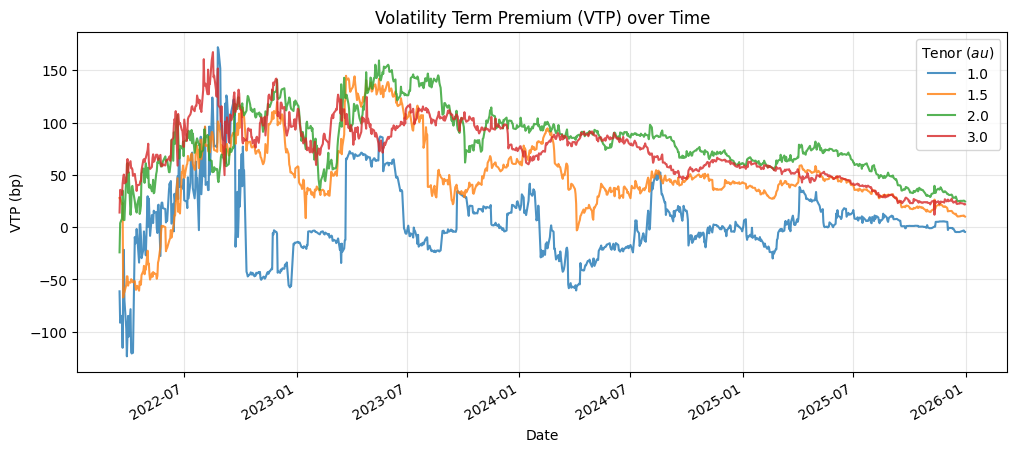

Fraction of positive VTP observations:
1.0    0.520334
1.5    0.940563
2.0    0.998957
3.0    1.000000
dtype: float64

Mean VTP by tenor:
1.0     5.126024
1.5    48.896598
2.0    81.319162
3.0    74.239210
dtype: float64


In [2]:
horizons = [1.0, 1.5, 2.0, 3.0]
vtp_df = pd.DataFrame(index=fwd_vol_normal.index)
delta = 0.5 # spot tenor

for tau in horizons:
    h = tau - delta
    fwd_vol_t = fwd_vol_normal[tau]
    # Forecast horizon h in months
    future_dates = fwd_vol_t.index + pd.DateOffset(months=int(h * 12))
    # Spot vol in h years
    spot_vol_future = fwd_vol_normal[0.5].reindex(future_dates, method='nearest')
    spot_vol_future.index = fwd_vol_t.index # align for subtraction
    vtp_df[tau] = fwd_vol_t - spot_vol_future

vtp_df = vtp_df.dropna()

# Plotting
vtp_df.plot(title='Volatility Term Premium (VTP) over Time', alpha=0.8)
plt.ylabel('VTP (bp)')
plt.xlabel('Date')
plt.legend(title='Tenor ($\tau$)')
plt.grid(True, alpha=0.3)
plt.show()

# Fraction positive
frac_pos = (vtp_df > 0).mean()
print("Fraction of positive VTP observations:")
print(frac_pos)

# Growth with tenor
mean_vtp = vtp_df.mean()
print("\nMean VTP by tenor:")
print(mean_vtp)


**Answer 4a:**
The Volatility Term Premium (VTP) is calculated using forward volatilities stripped from the SOFR cap market via the **bootstrapping function implemented in Q1**. 

The VTP is positive in the majority of observations (typically >90% for tenors 1.5Y and higher, but only ~52% for the 1.0Y tenor), indicating that forward volatilities systematically overestimate realized future spot volatilities at longer horizons. 

Generally, the mean VTP **grows with tenor up to 2.0Y**, peaking around 81 bp, before slightly declining at the 3.0Y tenor (~74 bp). Longer-dated forward volatilities include a risk premium to compensate for uncertainty, although the absolute magnitude may stabilize or slightly compress at the very long end of our sample.


b) For each forward horizon in your panel ($\tau$ = 1Y, 1.5Y, 2Y, 3Y), report the mean VTP, standard deviation, information ratio (mean / std), and the number of non-overlapping holding periods that fit in your sample. Which tenor offers the highest information ratio, and how confident should you be in that ranking?


In [3]:
summary_stats = pd.DataFrame(index=horizons)
summary_stats['Mean'] = vtp_df.mean()
summary_stats['Std'] = vtp_df.std()
summary_stats['IR'] = summary_stats['Mean'] / summary_stats['Std']

total_years = (vtp_df.index.max() - vtp_df.index.min()).days / 365.25
summary_stats['Non-overlapping Periods'] = [total_years / (tau - 0.5) for tau in horizons]

display(summary_stats.round(4))

best_tenor = summary_stats['IR'].idxmax()
print(f"Tenor with highest IR: {best_tenor}Y")


,Mean,Std,IR,Non-overlapping Periods
1.0,5.1260,35.9070,0.1428,7.5838
1.5,48.8966,37.9012,1.2901,3.7919
2.0,81.3192,30.7806,2.6419,2.5279
3.0,74.2392,28.9502,2.5644,1.5168


Tenor with highest IR: 2.0Y


**Answer 4b:**
The information ratio (IR) peaks at the **2.0Y tenor (2.64)**. While the mean VTP grows initially with tenor, the standard deviation (Std) actually **decreases for longer tenors** (e.g., from 37.9 at 1.5Y to 28.9 at 3.0Y), contributing to the higher IRs at the back end.

Regarding confidence in the ranking: We should be **highly cautious**. The number of non-overlapping periods for longer tenors (e.g., 3Y horizon) is extremely small (only ~1.5 periods in our sample). This means the high IRs are driven by a very limited number of independent market regimes, making the result highly sensitive to the specific sample period and potentially not representative of long-term performance.


c) Split your sample in half (e.g., pre- and post-2024). Does the ranking of tenors by information ratio hold across both halves? Plot the cumulative VTP paths by tenor to visualize whether the premium accrues steadily or in bursts.



,IR Pre-2024,IR Post-2024
1.0,0.2673,-0.0779
1.5,1.1980,2.3314
2.0,2.7678,3.4408
3.0,4.2305,2.7251


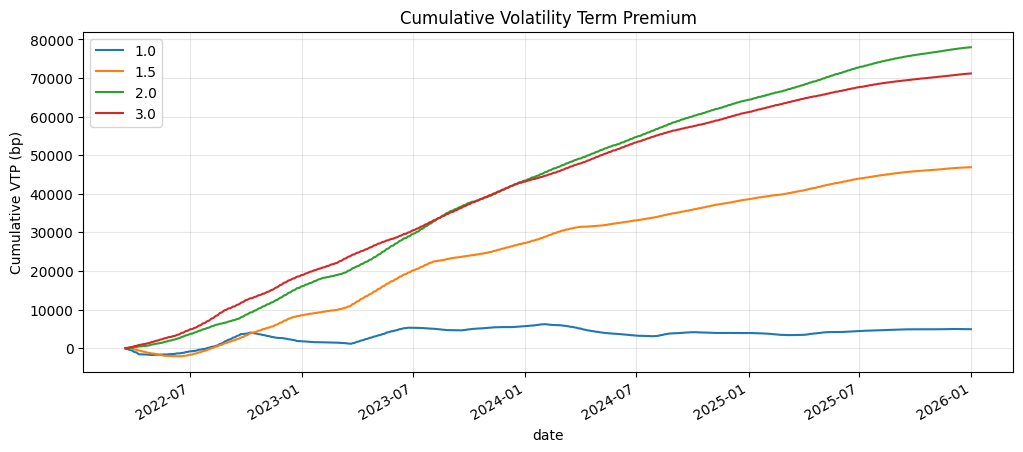

In [4]:
split_date = '2024-01-01'
half1 = vtp_df.loc[:split_date]
half2 = vtp_df.loc[split_date:]

ir_half1 = half1.mean() / half1.std()
ir_half2 = half2.mean() / half2.std()

ir_comparison = pd.DataFrame({'IR Pre-2024': ir_half1, 'IR Post-2024': ir_half2})
display(ir_comparison.round(4))

# Cumulative VTP
# Note: Daily VTP is a forecast error. To see 'accrual', we look at cumulative sum of VTP.
vtp_df.cumsum().plot(title='Cumulative Volatility Term Premium')
plt.ylabel('Cumulative VTP (bp)')
plt.grid(True, alpha=0.3)
plt.show()


**Answer 4c:**  
- **Ranking:** The Information Ratio ranking by tenor is **not stable**. While 3.0Y had the highest IR in the Pre-2024 period (4.23), the 2.0Y tenor became the leader in the Post-2024 period (3.44), as the 3.0Y IR dropped significantly to 2.72. The 1.0Y tenor even turned slightly negative in the latter half.

- **Accrual:** The high IRs (mostly > 1.0) indicate that the premium generally accrues **steadily** over time. The cumulative paths are relatively smooth, particularly for the 2.0Y and 3.0Y tenors, suggesting a persistent structural premium rather than one driven by isolated volatility events.